# E-Commerce Customer Churn Dataset — Cleaned & Fixed**Fixed in this version:**- Removed references to columns that don't exist in this dataset (`Order ID`, `Customer Name`, `Sales`, `Category`, `Profit`, `Order Date` belong to a different dataset).- `dropna()` / `drop_duplicates()` results are now actually assigned back.- File path fixed to a relative path.- Charts now use real columns from this dataset.- Final cleaned dataset exported to `E_Commerce_Dataset_cleaned.csv`.

In [1]:
import pandas as pdimport matplotlib.pyplot as pltimport seaborn as sns

### Load data

In [2]:
df = pd.read_csv('E_Commerce_Dataset.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>RangeIndex: 5630 entries, 0 to 5629Data columns (total 20 columns): #   Column                       Non-Null Count  Dtype  ---  ------                       --------------  -----   0   CustomerID                   5630 non-null   int64   1   Churn                        5630 non-null   int64   2   Tenure                       5366 non-null   float64 3   PreferredLoginDevice         5630 non-null   str     4   CityTier                     5630 non-null   int64   5   WarehouseToHome              5379 non-null   float64 6   PreferredPaymentMode         5630 non-null   str     7   Gender                       5630 non-null   str     8   HourSpendOnApp               5375 non-null   float64 9   NumberOfDeviceRegistered     5630 non-null   int64   10  PreferedOrderCat             5630 non-null   str     11  SatisfactionScore            5630 non-null   int64   12  MaritalStatus                5630 non-null   str     13  NumberOfAddress              5630 non-null   in

In [4]:
df.describe().round(2)

       CustomerID    Churn   Tenure  CityTier  WarehouseToHome  HourSpendOnApp  NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  OrderAmountHikeFromlastYear  CouponUsed  OrderCount  DaySinceLastOrder  CashbackAmountcount     5630.00  5630.00  5366.00   5630.00          5379.00         5375.00                   5630.00            5630.00          5630.00   5630.00                      5365.00     5374.00     5372.00            5323.00         5630.00mean     52815.50     0.17    19.40      1.75            22.06            2.63                      3.72               3.34             8.07      0.28                        18.53        8.15        8.45              10.49          224.51std       1625.39     0.37    15.09      0.77            10.01            1.32                      1.35               1.25             4.30      0.45                         4.60        4.93        4.53               6.35           72.39min      50001.00     0.00     0.00      1.00   

In [5]:
df.isnull().sum()

CustomerID                       0Churn                            0Tenure                         264PreferredLoginDevice             0CityTier                         0WarehouseToHome                251PreferredPaymentMode             0Gender                           0HourSpendOnApp                 255NumberOfDeviceRegistered         0PreferedOrderCat                 0SatisfactionScore                0MaritalStatus                    0NumberOfAddress                  0Complain                         0OrderAmountHikeFromlastYear    265CouponUsed                     256OrderCount                     258DaySinceLastOrder              307CashbackAmount                   0

In [6]:
df.shape

(5630, 20)

### Cleaning: remove duplicates and handle missing values

In [7]:
print('Duplicate rows:', df.duplicated().sum())df = df.drop_duplicates()

Duplicate rows: 0


In [8]:
numeric_cols = df.select_dtypes(include='number').columnsfor col in numeric_cols:    df[col] = df[col].fillna(df[col].median())df.isnull().sum()

CustomerID                     0Churn                          0Tenure                         0PreferredLoginDevice           0CityTier                       0WarehouseToHome                0PreferredPaymentMode           0Gender                         0HourSpendOnApp                 0NumberOfDeviceRegistered       0PreferedOrderCat               0SatisfactionScore              0MaritalStatus                  0NumberOfAddress                0Complain                       0OrderAmountHikeFromlastYear    0CouponUsed                     0OrderCount                     0DaySinceLastOrder              0CashbackAmount                 0

In [9]:
df.shape

(5630, 20)

### Explore categorical columns

In [10]:
for col in df.select_dtypes(include='object').columns:    print(df[col].value_counts())    print('_' * 50)

PreferredLoginDevice
Mobile Phone    2573
Phone           1960
Computer        1097
__________________________________________________
PreferredPaymentMode
Debit Card          1702
UPI                 1392
Credit Card         1154
Cash on Delivery     540
E wallet             470
CC                   219
COD                  153
__________________________________________________
Gender
Male      3406
Female    2224
__________________________________________________
PreferedOrderCat
Laptop & Accessory    1672
Mobile Phone          1406
Fashion                951
Grocery                697
Others                 566
Mobile                 338
__________________________________________________
MaritalStatus
Married     2858
Single      1939
Divorced     833
__________________________________________________


In [11]:
df.dtypes

CustomerID                       int64Churn                            int64Tenure                         float64PreferredLoginDevice               strCityTier                         int64WarehouseToHome                float64PreferredPaymentMode               strGender                             strHourSpendOnApp                 float64NumberOfDeviceRegistered         int64PreferedOrderCat                   strSatisfactionScore                int64MaritalStatus                      strNumberOfAddress                  int64Complain                         int64OrderAmountHikeFromlastYear    float64CouponUsed                     float64OrderCount                     float64DaySinceLastOrder              float64CashbackAmount                 float64

### Visualizations

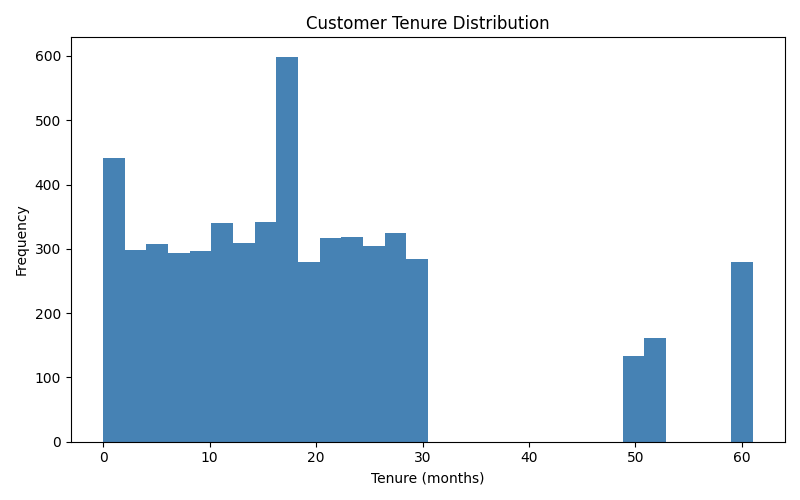

In [12]:
plt.figure(figsize=(8,5))plt.hist(df['Tenure'], bins=30)plt.title('Customer Tenure Distribution')plt.xlabel('Tenure (months)')plt.ylabel('Frequency')plt.show()

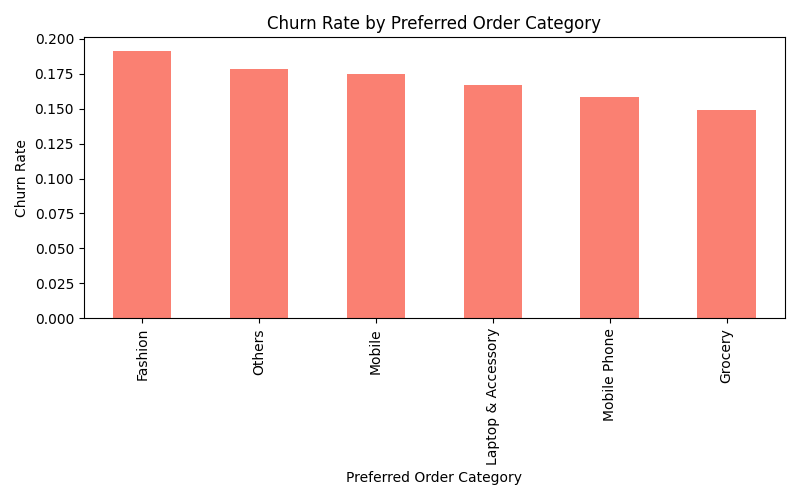

In [13]:
category_churn = df.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=False)plt.figure(figsize=(8,5))category_churn.plot(kind='bar')plt.title('Churn Rate by Preferred Order Category')plt.xlabel('Preferred Order Category')plt.ylabel('Churn Rate')plt.tight_layout()plt.show()

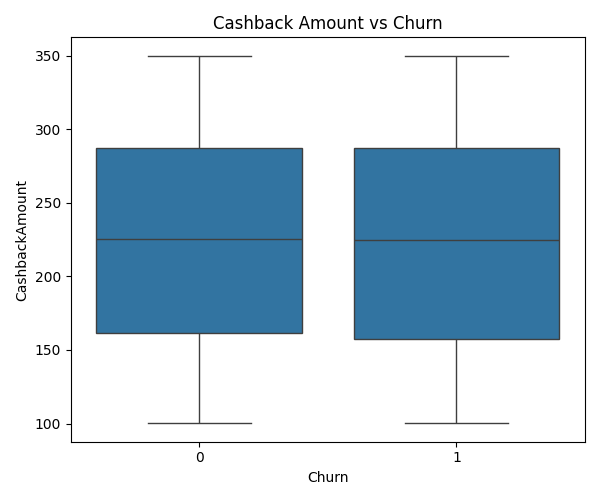

In [14]:
plt.figure(figsize=(6,5))sns.boxplot(x='Churn', y='CashbackAmount', data=df)plt.title('Cashback Amount vs Churn')plt.show()

### Export the cleaned dataset

In [15]:
df.to_csv('E_Commerce_Dataset_cleaned.csv', index=False)print('Saved cleaned dataset as E_Commerce_Dataset_cleaned.csv with shape:', df.shape)

Saved cleaned dataset as E_Commerce_Dataset_cleaned.csv with shape: (5630, 20)
